# 24. Catalog-driven car co-design from a single architecture table

Notebook **17** modelled the full-vehicle co-design with three hand-wired builders (`build_ice_car`, `build_hybrid_car`, `build_ev_car`), one per powertrain family. Each builder wires its own subsystem graph and knows, in Python, which modules an ICE, a hybrid, or an EV needs. That is expressive but it hard-codes the architecture space into three functions.

This notebook takes the *catalog-driven* stance instead. A single **12-row `ARCHITECTURE_CATALOG`** enumerates the modern powertrain spectrum -- pure ICE, diesel, mild hybrid (MHEV), full hybrid (FHEV), plug-in hybrid (PHEV), range-extender EV (REEV), and battery-electric (BEV) -- and **one** `build_architecture()` function assembles a solvable `System` for *any* row. The discrete powertrain choices (engine, transmission, e-motor) become one-entry `CatalogDP` slices of master catalogs; the parametric modules (cooling, fuel, battery, brakes, suspension, tyres, ...) size themselves from mission demand and from the converged curb mass. The body, suspension, and tyres stay full `CatalogDP`s, so the solver still picks the cheapest chassis that satisfies the mission.

The result is that adding an architecture is adding a row to a table, not writing a new builder. The same two coupled cycles as notebook 17 are closed by the Kleene iteration: the **mass spiral** (subsystem weights sum to curb weight, which feeds back as the design mass every load-bearing module must support) and the **BEV energy spiral** (battery sized to range x consumption, whose own mass raises consumption).

One design decision matters for the numbers: the energy metric is *unified primary energy* per 100 km (fuel lower-heating-value **plus** battery/grid electricity). This is why an ICE lands near 45-55 kWh/100 km while a BEV lands near 15 kWh/100 km -- the combustion path throws away most of the fuel's chemical energy as heat. All the calibration numbers are internet-sourced; see the `SOURCES` block in the example's module docstring (BNEF 2024 pack prices, pack-level Wh/kg, fuel LHV/CO2, Corolla curb-mass bracket).


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'car_catalog', os.path.join(PROJECT_ROOT, 'examples', '24_car_catalog_codesign.py'))
car = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(car)

from codesign import solve
print("Module loaded.")
print(f"  Architecture rows : {len(car.ARCHITECTURE_CATALOG)}")
print(f"  Engine catalog    : {len(car.ENGINE_CATALOG)}")
print(f"  Transmission cat. : {len(car.TRANSMISSION_CATALOG)}")
print(f"  E-motor catalog   : {len(car.EMOTOR_CATALOG)}")
print(f"  Body catalog      : {len(car.BODY_CATALOG)}")
print(f"  Suspension catalog: {len(car.SUSPENSION_CATALOG)}")
print(f"  Tire catalog      : {len(car.TIRE_CATALOG)}")

Module loaded.
  Architecture rows : 12
  Engine catalog    : 8
  Transmission cat. : 5
  E-motor catalog   : 6
  Body catalog      : 5
  Suspension catalog: 4
  Tire catalog      : 5


## The mission

One representative compact C-segment mission drives the whole study: 5 seats, 370 L of cargo, 170 km/h top speed, 500 km of range, 0-100 km/h in 11.5 s. The targets are bracketed by the 2024 Toyota Corolla figures cited in the example's SOURCES block.


In [2]:
print("Mission:", car.mission_str(car.MISSION))
for k, v in car.MISSION.items():
    print(f"  {k:<20} = {v}")

Mission: 5 seats, 370 L, 170 km/h top, 500 km range, 0-100 in 11.5 s
  passenger_capacity   = 5
  cargo_volume_L       = 370.0
  max_speed_kmh        = 170.0
  target_range_km      = 500.0
  accel_0_100_s        = 11.5


## The architecture catalog

Each row pre-selects the discrete powertrain (an index into the engine, transmission, and e-motor catalogs) plus its energy strategy (target battery kWh, on-board charger, ICE cruise fraction, AWD/diesel flags). `ARCH_CLASS` groups the twelve rows into the six powertrain classes used by the comparison table at the end.


In [3]:
print(f"{'architecture':<18}{'class':<7}{'engine':<16}{'e-motor':<13}"
      f"{'batt kWh':>9}{'ice_f':>7}")
print("-" * 70)
for entry in car.ARCHITECTURE_CATALOG:
    arch = car.architecture_by_name(entry[0])
    eng = car.ENGINE_CATALOG[arch['engine_idx']][0]
    em  = car.EMOTOR_CATALOG[arch['emotor_idx']][0]
    print(f"{arch['name']:<18}{car.ARCH_CLASS[arch['name']]:<7}{eng:<16}{em:<13}"
          f"{arch['target_battery_kWh']:>9.0f}{arch['ice_fraction']:>7.2f}")

architecture      class  engine          e-motor       batt kWh  ice_f
----------------------------------------------------------------------
ICE_economy       ICE    1.0L_3cyl_T     none_ice             0   1.00
ICE_family        ICE    1.5L_4cyl_T     none_ice             0   1.00
ICE_premium       ICE    2.0L_4cyl_T     none_ice             0   1.00
ICE_performance   ICE    3.0L_V6_T       none_ice             0   1.00
Diesel_long_range ICE    2.0L_4cyl_TD    none_ice             0   1.00
MHEV_48V          MHEV   1.5L_4cyl_T     isg_48V              1   0.95
HEV_full          FHEV   1.5L_4cyl_NA    front_small          2   0.60
PHEV_small        PHEV   1.5L_4cyl_T     front_med           16   0.50
PHEV_large        PHEV   2.0L_4cyl_T     front_large         25   0.40
REEV              REEV   1.0L_REX        front_large         55   0.20
BEV_long_range    BEV    none_ev         front_large         80   0.00
BEV_AWD_perf      BEV    none_ev         dual_perf          100   0.00


## Solve the whole table

`solve_architecture` takes one architecture row and sweeps the eligible chassis catalog (body x suspension x tyre), building a single-valued `System` for each combination, closing the mass and energy spirals with `solve()`, and keeping the cheapest feasible converged design. We run it for all twelve rows and print the feasibility table -- the cheapest feasible design per architecture, with its curb mass, unified energy/100 km, fuel/100 km, and tailpipe CO2.


In [4]:
import time
t0 = time.time()

solved = []                 # (arch_name, best_point) for feasible rows
table  = []                 # (name, class, feasible, best) for every row
for entry in car.ARCHITECTURE_CATALOG:
    arch = car.architecture_by_name(entry[0])
    feasible, best = car.solve_architecture(arch, car.MISSION)
    if feasible:
        solved.append((arch['name'], best))
    table.append((arch['name'], car.ARCH_CLASS[arch['name']], feasible, best))
elapsed = time.time() - t0

header = (f"  {'Architecture':<18}{'cls':<6}{'feas':<6}"
          f"{'cost$':>9}{'mass kg':>9}{'kWh/100':>9}{'L/100':>7}{'CO2':>7}")
print(header)
print("  " + "-" * (len(header) - 2))
for name, cls, feasible, best in table:
    if not feasible:
        print(f"  {name:<18}{cls:<6}{'no':<6}{'-':>9}{'-':>9}{'-':>9}{'-':>7}{'-':>7}")
        continue
    print(f"  {name:<18}{cls:<6}{'yes':<6}"
          f"{best['production_cost_USD']:>9,.0f}{best['curb_weight_kg']:>9.0f}"
          f"{best['energy_per_100km_kWh']:>9.1f}{best['fuel_per_100km_L']:>7.1f}"
          f"{best['co2_per_km']:>7.0f}")
print(f"\n{len(solved)}/{len(car.ARCHITECTURE_CATALOG)} architectures feasible "
      f"(whole table swept in {elapsed:.1f}s)")

  Architecture      cls   feas      cost$  mass kg  kWh/100  L/100    CO2
  -----------------------------------------------------------------------
  ICE_economy       ICE   yes      17,447      930     47.8    5.3    123
  ICE_family        ICE   yes      22,029     1018     47.8    5.3    123
  ICE_premium       ICE   yes      24,711     1071     47.9    5.4    124
  ICE_performance   ICE   yes      31,981     1191     53.1    5.9    137
  Diesel_long_range ICE   yes      24,400     1081     40.6    4.1    109
  MHEV_48V          MHEV  yes      24,683     1098     46.9    5.2    119
  HEV_full          FHEV  yes      26,945     1315     42.2    4.1     94
  PHEV_small        PHEV  yes      36,162     1537     34.9    3.1     71
  PHEV_large        PHEV  yes      43,990     1769     32.3    2.5     59
  REEV              REEV  yes      37,182     1613     21.6    1.1     26
  BEV_long_range    BEV   yes      44,572     1788     14.8    0.0      0
  BEV_AWD_perf      BEV   yes      68,

## The Pareto front over (cost, energy, mass)

The cheapest feasible design of each architecture is one point in a three-objective space: production cost, unified energy per 100 km, and curb mass. `_pareto` keeps the non-dominated ones -- the designs for which no other architecture is at least as good on all three axes and strictly better on one.


In [5]:
axes = ("production_cost_USD", "energy_per_100km_kWh", "curb_weight_kg")
front = car._pareto(solved, axes)
front_names = {name for name, _ in front}
print("Pareto front over (cost, energy/100km, mass):")
for name, p in sorted(front, key=lambda t: t[1]['production_cost_USD']):
    print(f"  {name:<18} ${p['production_cost_USD']:>8,.0f}"
          f"  {p['energy_per_100km_kWh']:>5.1f} kWh/100"
          f"  {p['curb_weight_kg']:>5.0f} kg")

Pareto front over (cost, energy/100km, mass):
  ICE_economy        $  17,447   47.8 kWh/100    930 kg
  Diesel_long_range  $  24,400   40.6 kWh/100   1081 kg
  PHEV_small         $  36,162   34.9 kWh/100   1537 kg
  REEV               $  37,182   21.6 kWh/100   1613 kg
  BEV_long_range     $  44,572   14.8 kWh/100   1788 kg


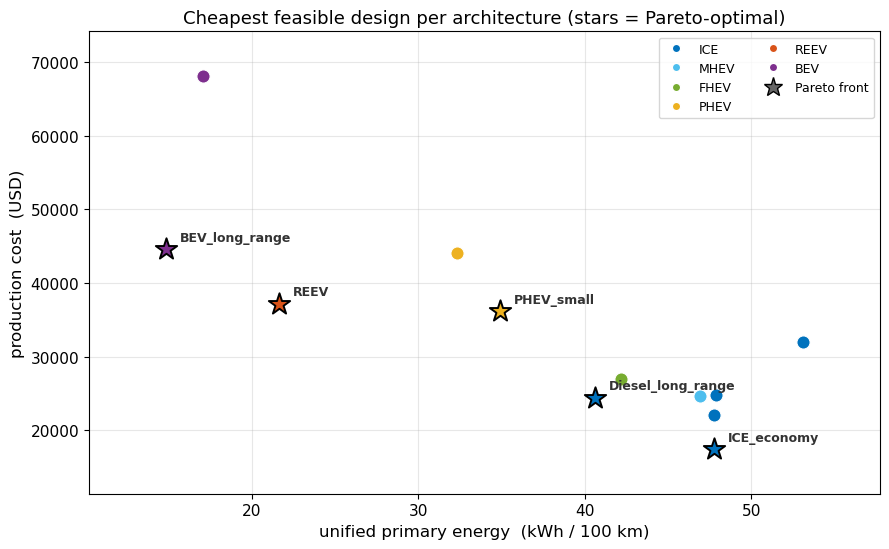

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# MATLAB gem colours, one per powertrain class.
CLASS_COLOR = {"ICE": "#0072BD", "MHEV": "#4DBEEE", "FHEV": "#77AC30",
               "PHEV": "#EDB120", "REEV": "#D95319", "BEV": "#7E2F8E"}

fig, ax = plt.subplots(figsize=(9.0, 5.6))
for name, p in solved:
    cls = car.ARCH_CLASS[name]
    on_front = name in front_names
    ax.scatter(p['energy_per_100km_kWh'], p['production_cost_USD'],
               s=260 if on_front else 90,
               marker="*" if on_front else "o",
               color=CLASS_COLOR[cls],
               edgecolor="black" if on_front else "white",
               linewidth=1.4 if on_front else 0.8,
               zorder=4 if on_front else 2)
    # Label only the Pareto-optimal (star) points -- they are well separated,
    # so their names never collide. The clustered non-front designs (several
    # near-identical ICE/MHEV variants) are left to the class legend rather
    # than overprinting each other; the feasibility table above names them.
    if on_front:
        ax.annotate(name, (p['energy_per_100km_kWh'], p['production_cost_USD']),
                    textcoords="offset points", xytext=(10, 6),
                    fontsize=9, color="0.2", fontweight="bold")
ax.set_xlabel("unified primary energy  (kWh / 100 km)", fontsize=12)
ax.set_ylabel("production cost  (USD)", fontsize=12)
ax.set_title("Cheapest feasible design per architecture "
             "(stars = Pareto-optimal)", fontsize=13)
ax.margins(0.12)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)

handles = [Line2D([], [], marker="o", linestyle="none", color=c, label=cls,
                  markeredgecolor="white") for cls, c in CLASS_COLOR.items()]
handles.append(Line2D([], [], marker="*", linestyle="none", color="0.4",
                      markersize=14, markeredgecolor="black", label="Pareto front"))
ax.legend(handles=handles, fontsize=9, frameon=True, ncol=2, loc="upper right")
fig.tight_layout()
plt.show()

## Comparison by powertrain class

Collapsing to the cheapest feasible design in each of the six classes reads off the headline trade: cost climbs and tailpipe CO2 falls as the architecture electrifies, with the REEV and BEV eliminating (or nearly eliminating) tailpipe emissions at the top of the cost range.


In [7]:
print(f"  {'class':<6}{'best arch':<18}{'cost$':>9}{'mass kg':>9}"
      f"{'kWh/100':>9}{'CO2 g/km':>10}")
by_class = {}
for name, p in solved:
    cls = car.ARCH_CLASS[name]
    if cls not in by_class or \
       p['production_cost_USD'] < by_class[cls][1]['production_cost_USD']:
        by_class[cls] = (name, p)
for cls in ("ICE", "MHEV", "FHEV", "PHEV", "REEV", "BEV"):
    if cls not in by_class:
        continue
    name, p = by_class[cls]
    print(f"  {cls:<6}{name:<18}{p['production_cost_USD']:>9,.0f}"
          f"{p['curb_weight_kg']:>9.0f}{p['energy_per_100km_kWh']:>9.1f}"
          f"{p['co2_per_km']:>10.0f}")

  class best arch             cost$  mass kg  kWh/100  CO2 g/km
  ICE   ICE_economy          17,447      930     47.8       123
  MHEV  MHEV_48V             24,683     1098     46.9       119
  FHEV  HEV_full             26,945     1315     42.2        94
  PHEV  PHEV_small           36,162     1537     34.9        71
  REEV  REEV                 37,182     1613     21.6        26
  BEV   BEV_long_range       44,572     1788     14.8         0


## What the catalog-driven approach delivers

Compared with notebook 17's three hand-wired builders, this study spans the *same* architectural breadth -- and more (it adds MHEV, FHEV, PHEV, and REEV as distinct rows) -- from a single table and a single `build_architecture()` function. Every powertrain choice is a `CatalogDP` entry rather than a bespoke `Module`, and the mass and BEV-energy spirals are closed by the same Kleene solver.

Three patterns fall out of the Pareto front and the class comparison:

1. **ICE wins on upfront cost**, by a wide margin, because it carries no traction battery or power electronics. The cheapest feasible ICE sits well below any electrified option.

2. **Unified primary energy falls monotonically with electrification.** The ICE burns roughly three times the primary energy per 100 km of the BEV, because combustion rejects most of the fuel's chemical energy as heat -- the unified metric makes that visible where an "L/100 km vs kWh/100 km" comparison would hide it.

3. **Tailpipe CO2 tracks the ICE cruise fraction**, reaching zero for the pure BEVs. The PHEV/REEV rows interpolate: a small battery plus an engine buys most of the CO2 reduction at a fraction of the BEV's cost and mass.

The framework's contribution is the same as in notebook 17 -- every subsystem R port is exposed in the antichain and every constraint is one line -- but here the *architecture space itself* is data. Widening the study is editing a table, and the same monotone-resource machinery resolves each row's coupled spirals automatically. The calibration numbers are internet-sourced (see the example's `SOURCES` block); they are illustrative, not OEM-specific, and it is the co-design framework that is being validated.
